In [9]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt

import sys
import os
from pathlib import Path

# move upward until we find repo root
repo_root = Path.cwd()

while not (repo_root / ".git").exists():
    repo_root = repo_root.parent

sys.path.append(str(repo_root))
from config import config
from DataPipeline.utils.bets_utils import generate_bets 

In [5]:
df_ml_history = pd.read_csv(config.ml_history_fp)
print(df_ml_history.shape)
df_ml_history = df_ml_history.drop_duplicates(subset=['fighter_red', 'fighter_blue', 'date'], keep='first')
print(df_ml_history.shape)

(52, 20)
(26, 20)


In [6]:
df_ml_history.columns

Index(['fighter_red', 'fighter_blue', 'winner', 'pred_name_open',
       'pred_name_close1', 'pred_name_close2', 'open_red', 'open_blue',
       'close1_red', 'close1_blue', 'close2_red', 'close2_blue',
       'net_odds_open', 'net_odds_close1', 'net_odds_close2', 'fstar_open',
       'fstar_close1', 'fstar_close2', 'date', 'winner_bool'],
      dtype='object')

In [8]:
df_parlay = pd.read_csv(config.parlay_history_fp)
df_parlay.columns

Index(['choice_fighter_name_open', 'choice_fighter_name_close1',
       'choice_fighter_name_close2', 'open_net_fstar', 'close1_net_fstar',
       'close2_net_fstar', 'open_net_odds', 'close1_net_odds',
       'close2_net_odds', 'date'],
      dtype='object')

In [ ]:
def returns_by_date():
    
    df_ml = pd.read_csv(config.ml_history_fp)
    df_parlay = pd.read_csv(config.parlay_history_fp)

    types = ['open', 'close1', 'close2']
    ml_pct_returns = {type_:[] for type_ in types}
    parlay_pct_returns = {type_:[] for type_ in types}

    ml_pct_returns['date'] = []
    parlay_pct_returns['date'] = [] 

    for date, group in df_ml.groupby('date'): 
        
        parlay_group = df_parlay[df_parlay['date']==date]

        for type_ in types: 

            total_net_odds = np.sum(np.where(group[f'fstar_{type_}'] > 0, group[f'net_odds_{type_}'], 0))
            ml_pct_returns[type_].append(total_net_odds)

            valid_parlay = parlay_group[f'{type_}_fstar'].iloc[0] > 0 
            total_net_odds = group[f'{type_}_net_odds'].iloc[0] if valid_parlay else 0 
            parlay_pct_returns[type_].append(total_net_odds)
        
        ml_pct_returns['date'].append(date)
        parlay_pct_returns['date'].append(date)

    df_ml_pct = pd.DataFrame(ml_pct_returns)
    df_parlay_pct = pd.DataFrame(parlay_pct_returns)

    return df_ml_pct, df_parlay_pct


df_ml_pct, df_parlay_pct = returns_by_date()


(array([1., 0., 0., 0., 0., 0., 0., 0., 0., 1.]),
 array([-1.23379521, -1.20634279, -1.17889038, -1.15143796, -1.12398555,
        -1.09653313, -1.06908072, -1.0416283 , -1.01417589, -0.98672347,
        -0.95927105]),
 <BarContainer object of 10 artists>)

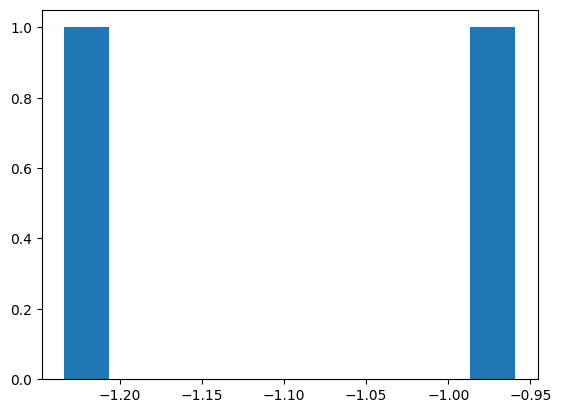

In [13]:
plt.hist(df_ml_pct['open'])

In [4]:
df_ml_history = df_ml_history.drop_duplicates(subset=['fighter_red', 'fighter_blue'])
print(df_ml_history.shape)

(192, 20)


In [2]:
folder_path = r"C:\Users\jcmar\my_files\SportsBetting\Data\upcoming_events\event_features"

file_path = os.path.join(folder_path, "upcoming_odds_stats_2026-06-06.csv")
print(file_path)

upcoming_fp = fr'{file_path}'
upcoming_df = pd.read_csv(upcoming_fp)  

df_bets_all, df_parlay_all = generate_bets(upcoming_df)




C:\Users\jcmar\my_files\SportsBetting\Data\upcoming_events\event_features\upcoming_odds_stats_2026-06-06.csv
Constant-like columns: ['const']
Constant-like columns: ['const']
Constant-like columns: ['const']
0     0.282688
1     0.205283
2     0.219648
3     0.098323
4     0.014437
5     0.201905
6     0.007705
7     0.120093
8     0.102102
9          NaN
10    0.257567
11    0.000000
Name: fstar_scaled, dtype: float64
0     0.283114
1     0.205430
2     0.218685
3     0.065025
4     0.092367
5     0.219545
6     0.000000
7     0.119642
8     0.106465
9          NaN
10    0.260677
11    0.000000
Name: fstar_scaled, dtype: float64


In [4]:
upcoming_df[['open_red', 'open_blue', 'close2_red', 'close2_blue']] 

,open_red,open_blue,close2_red,close2_blue
0,-450.0,350.0,-520.0,400.0
1,-350.0,285.0,-225.0,195.0
2,-185.0,160.0,-275.0,250.0
3,220.0,-260.0,-250.0,220.0
4,400.0,-550.0,550.0,-549.0
5,-250.0,210.0,-155.0,135.0
6,-110.0,-110.0,-132.0,115.0
7,-110.0,-110.0,100.0,-120.0
8,330.0,-400.0,165.0,-175.0
9,-900.0,600.0,-350.0,310.0
